# Question 3:
Tackle the Titanic dataset. A great place to start is on Kaggle(https://kaggle.com/c/titanic). Alternatively, you can download the data from https://homl.info/titanic/titanic.tgz and unzip this tarball like you did 
for the housing data in Chapter 2. This will give you two CSV files, train.csv and test.csv, which you can load using `pandas.read_csv()`. The goal is to train a classifier that can predict the `Survived` column based
on the other columns

In [ ]:
import pandas as pd
pd.options.mode.copy_on_write = True
# I have downloaded the dataset from kaggle and put it in a folder ch3
# the code below assumes that the folder ch3 is in the same folder as notebook
train = pd.read_csv("./ch3/train.csv")
test = pd.read_csv("./ch3/test.csv")
gender_submission = pd.read_csv("./ch3/gender_submission.csv")

Lookign at the data we have below, I just jotted down some initial thoughts about the attributes we have.
- **PassengerId**: This looks like a unique identifier for the passengers, so don't think this will help us much.
- **Survived**: We need to separate this out as our target
- **Pclass**: The passenger classes, 1st, 2nd, and 3rd. Probably an indicator of how well-off the people are, and might provide interesting insight into the survivorship.
- **Name**: - While the name itself might not be a useful value, perhaps it can be used to derive additional features e.g. identifying who was in a family together, their relationships etc.
- **Sex**: definitely going to be super helpful. But since this is a categorical attribute we might need to hot encode this, or convert it into a simple 1 and 0
- **Age**: This too would have been a useful indicator, however, I looked into the ages more and it looks like the age is missing for a large number of our datapoints. Can we reliably replace these? Too many of them are missing, I'm more inclined to drop this column. But let's not get ahead of ourselves.
- **SibSp**: Singlings and spouses. Once again useful for verifying family, not sure if it is useful to use raw. Calculating a correlation matrix for them might help.
- **Parch**: parents and children aboard the titanic. Same as SibSp
- **Ticket**: Not sure how helpful this is, it just looks like a bunch of strings with no pattern (on first glance at least)
- **Fare**: How much money was spent by the passenger. Question: How does this show for groups?
- **Cabin**: It follows the patter 'Alphabet+Number', perhaps if we can split these up, the letter can give us a group e.g. berth class etc, while the number might indicate the location on the floor.
- **Embarked**: Not sure if death discriminates by who got on where, but the correlation matrix should help us figure that out.

In [2]:
print(f"Size of training.csv: {len(train)}")
train.head()

Size of training.csv: 891


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We have a test set here. We can use this to test our model at the end. **NOTE**: there target class doesn't exist in the below test set.
This is because we will have to upload our prediction results onto kaggle to get our score. The `gender_submission.csv` is the format
in which it expects the output to be uploaded.

In [3]:
print(f"Size of test.csv: {len(test)}")
test.head()

Size of test.csv: 418


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
gender_submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


### Explore the Data
Let's look further into the data and see if we can identify any gaps or opportunities to improve out predictive power.

In [5]:
data_set = train.copy()
data_set.columns = ["passenger_id", "survived", "p_class", "name", "sex", "age", "siblings_and_spouses", "parents_and_children", "ticket", "fare", "cabin", "embarked"]

In [6]:
data_set.dtypes

passenger_id              int64
survived                  int64
p_class                   int64
name                     object
sex                      object
age                     float64
siblings_and_spouses      int64
parents_and_children      int64
ticket                   object
fare                    float64
cabin                    object
embarked                 object
dtype: object

In [7]:
data_set.describe()

,passenger_id,survived,p_class,age,siblings_and_spouses,parents_and_children,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
null_counts = data_set.isnull().sum()
non_null_counts = data_set.notnull().sum()

# Compute ratios
total_counts = len(data_set)
null_ratios = null_counts / total_counts
# Combine results into a DataFrame
result = pd.DataFrame({
    'null_count': null_counts,
    'non_null_count': non_null_counts,
    'null_percentage': ((null_counts / total_counts) * 100).map('{:.2f}%'.format)
}).sort_values('null_count', ascending=False)
result

,null_count,non_null_count,null_percentage
cabin,687,204,77.10%
age,177,714,19.87%
embarked,2,889,0.22%
passenger_id,0,891,0.00%
survived,0,891,0.00%
p_class,0,891,0.00%
name,0,891,0.00%
sex,0,891,0.00%
siblings_and_spouses,0,891,0.00%
parents_and_children,0,891,0.00%


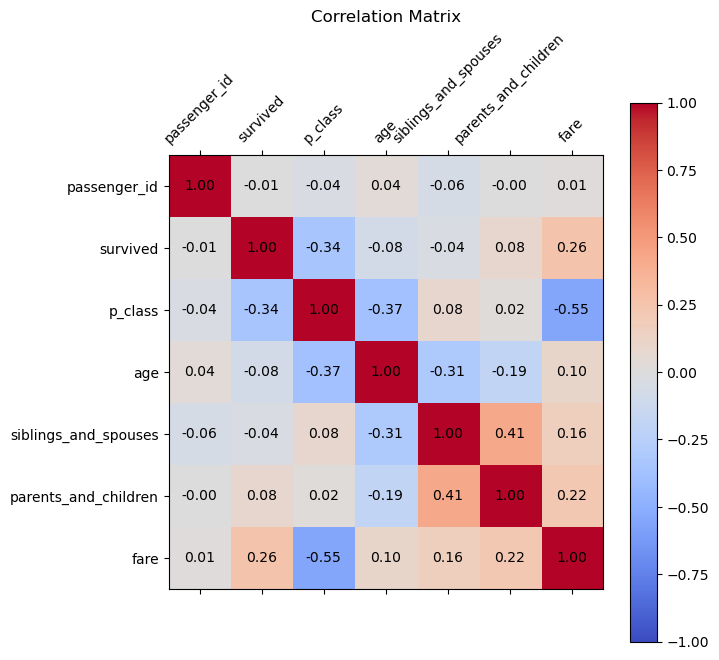

In [9]:
import matplotlib.pyplot as plt

corr_matrix = data_set.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 7))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add colorbar
fig.colorbar(cax)

# Set axis labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticklabels(corr_matrix.columns)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add correlation values inside the cells
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = f"{corr_matrix.iloc[i, j]:.2f}"
        ax.text(j, i, text, ha='center', va='center', color='black')

plt.title("Correlation Matrix")
plt.show()

Based on the correllation matrix above we see that:
- There is a positive correllation between the `fare` and `survived`. The higher the fare the more chance of survival.
- There is a negative correllation between `class` and `survived`. The lower the class (meaning higher the class number) the lower chance of survival.
- The attributes don't seem to be very strongly correlated to one another.
- The next highest are `parents_and_children` and `age`, both of which are positively correlated - but also, age has a lot of nulls in there that we need to handle for.

In [10]:
survival_by_sex = (data_set.groupby('sex')['survived'].mean() * 100).map('{:.2f}%'.format)
survival_by_embarked = (data_set.groupby('embarked')['survived'].mean() * 100).map('{:.2f}%'.format)

print("By Sex")
print(survival_by_sex)
print("")

print("By Embarked")
print(survival_by_embarked)

By Sex
sex
female    74.20%
male      18.89%
Name: survived, dtype: object

By Embarked
embarked
C    55.36%
Q    38.96%
S    33.70%
Name: survived, dtype: object


Of the object fields we see that:
- There is a high likelihood of survival if your `sex` is `female`.
- In the case of the `embarked` attribute, there is a higher chance of survival if you embarked from `C`. But the other's are fairly close too.

#### Embarked

In [11]:
print(f'Unique values for {data_set["embarked"].unique()}')

Unique values for ['S' 'C' 'Q' nan]


In [12]:
data_set.groupby(["p_class", "embarked"]).count()["passenger_id"]

p_class  embarked
1        C            85
         Q             2
         S           127
2        C            17
         Q             3
         S           164
3        C            66
         Q            72
         S           353
Name: passenger_id, dtype: int64

In [13]:
data_set[data_set["embarked"].isnull()]

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


I was initially going to spend some time doing analysis to see if we can figure out what values we can set for the missing
values of embarked. However, there are only 2 rows missing this value, and they both have the same ticket and cabin. We can make
a reasonable assumption that they embarked from the same place.

There are only 3 possible placed they could have embarked from. So, when we come to testing out mode we can try
each value out and see which gives us the best result. For now, I will try with S as they both are from 1st class, and most of the first class people have an embarked as `S`

#### Age

Age is a lot more challenging. One would assume that it would have a stronger correlation with the survived class, but
it seems to be correlated only by about `0.08` unlike some of the other attributes. I considered that the nulls could be having an effect, but the `corr` method excludes empty values when computing the correlation.

I'm tempted to ignore age, but maybe if we can fill in the remaing 20% we migth improve the predictability based on age.


- Looking at the correlation matrix `p_class` and `siblings_and_spouses` has the highest correlation with age. Maybe that is promissing.
- Additionally, the name attribute has the title of individuals in it e.g. Mr. Ms. Mrs. maybe that can help us out too.

In [17]:
data_set[["last_name", "first_name"]] = data_set["name"].str.split(',', n=1, expand=True)
data_set["title"] = data_set["first_name"].str.split(".").str[0]

aged_df = data_set[data_set["age"].notnull()]

As we can see below, a group doesn't need to be related only by family or last name to be considered a group. I wonder if the younger
ladies below might be assistants to the countess. They don't seem to share any titles.

In [18]:
aged_df["title"].unique()

array([' Mr', ' Mrs', ' Miss', ' Master', ' Don', ' Rev', ' Dr', ' Mme',
       ' Ms', ' Major', ' Lady', ' Sir', ' Mlle', ' Col', ' Capt',
       ' the Countess', ' Jonkheer'], dtype=object)

In [19]:
data_set[data_set["age"].notnull()].groupby(["title", "p_class"]).agg(
    age_mean=('age', 'mean'),
    count=('title', 'count')
)

age_mean  count
title        p_class                  
Capt         1        70.000000      1
Col          1        58.000000      2
Don          1        40.000000      1
Dr           1        43.750000      4
             2        38.500000      2
Jonkheer     1        38.000000      1
Lady         1        48.000000      1
Major        1        48.500000      2
Master       1         5.306667      3
             2         2.258889      9
             3         5.350833     24
Miss         1        30.000000     45
             2        22.390625     32
             3        16.123188     69
Mlle         1        24.000000      2
Mme          1        24.000000      1
Mr           1        41.580460     87
             2        32.768293     82
             3        28.724891    229
Mrs          1        40.882353     34
             2        33.682927     41
             3        33.515152     33
Ms           2        28.000000      1
Rev          2        43.166667      6
Sir          1        49.000000      1
the Countess 1        33.000000      1

In [20]:
data_set[data_set["age"].isnull()].groupby(["title", "p_class"]).count().sort_values(by=["title", "p_class"])["name"]

title   p_class
Dr      1           1
Master  3           4
Miss    1           1
        2           2
        3          33
Mr      1          20
        2           9
        3          90
Mrs     1           8
        3           9
Name: name, dtype: int64

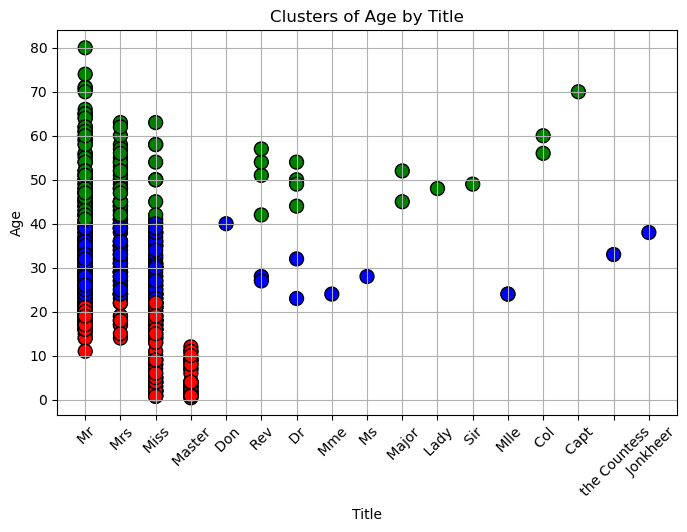

In [21]:
from sklearn.cluster import KMeans

title_mapping = {title.strip(): idx for idx, title in enumerate(aged_df['title'].unique())}
aged_df['title_num'] = aged_df['title'].str.strip().map(title_mapping)

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
aged_df['cluster'] = kmeans.fit_predict(aged_df[['title_num', 'age', 'p_class', 'siblings_and_spouses', 'parents_and_children']])

# Define colors for clusters
colors = ['red', 'green', 'blue']
cluster_colors = [colors[c] for c in aged_df['cluster']]

# Scatter plot with clusters
plt.figure(figsize=(8, 5))
plt.scatter(aged_df['title_num'], aged_df['age'], c=cluster_colors, edgecolors='black', s=100)

# Set x-ticks to show actual title names
plt.xticks(ticks=aged_df['title_num'].unique(), labels=aged_df['title'].unique(), rotation=45)
plt.xlabel("Title")
plt.ylabel("Age")
plt.title("Clusters of Age by Title")
plt.grid(True)
plt.show()

We can use regression to fill in the values for age, based on attributes that are correlated with it.

#### Cabin

In the case of cabin we are missing a value for this, for about 77% of our data. This sucks. I wonder if we can fill them in.

The general idea here is to identify travelers who were travelling together. If we can identify a group, and one of them has a cabin, we could assume that the rest
have the same of similar cabin. The attributes that will help us identify these groups are:
- ticket
- p_class
- name
- last_name
- siblings_and_spouses
- parents_and_children
- embarked

In [19]:
len(data_set[data_set["cabin"].isnull()])

687

Identify people that have the same ticket and forward fill those.

In [20]:
data_set['cabin_by_ticket'] = data_set.groupby(['p_class', 'ticket', "embarked"])['cabin'].ffill()
len(data_set[data_set["cabin_by_ticket"].isnull()])

684

In [21]:
tickets = data_set[data_set["cabin"].isnull() & data_set['cabin_by_ticket'].notnull()]["ticket"].unique()
data_set[data_set["ticket"].isin(tickets)].sort_values(["ticket"])[["p_class", "name", "cabin", "ticket", "embarked", "cabin_by_ticket"]]

,p_class,name,cabin,ticket,embarked,cabin_by_ticket
297,1,"Allison, Miss. Helen Loraine",C22 C26,113781,S,C22 C26
305,1,"Allison, Master. Hudson Trevor",C22 C26,113781,S,C22 C26
498,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",C22 C26,113781,S,C22 C26
708,1,"Cleaver, Miss. Alice",NaN,113781,S,C22 C26
128,3,"Peter, Miss. Anna",F E69,2668,C,F E69
533,3,"Peter, Mrs. Catherine (Catherine Rizk)",NaN,2668,C,F E69
318,1,"Wick, Miss. Mary Natalie",C7,36928,S,C7
856,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",NaN,36928,S,C7
269,1,"Bissette, Miss. Amelia",C99,PC 17760,S,C99
325,1,"Young, Miss. Marie Grice",C32,PC 17760,C,C32


Identify people that have the same last_name and forward fill those.

In [22]:
data_set['cabin_by_last_name'] = data_set.groupby(['p_class', 'last_name'])['cabin'].ffill()
len(data_set[data_set["cabin_by_last_name"].isnull()])

682

In [23]:
lnames = data_set[data_set["cabin"].isnull() & data_set['cabin_by_last_name'].notnull()]["last_name"].unique()
data_set[data_set["last_name"].isin(lnames)].sort_values(["last_name"])[["p_class", "last_name", "name", "cabin", "ticket", "cabin_by_last_name",
                                                                         "siblings_and_spouses", "parents_and_children", "age", "embarked"]]

,p_class,last_name,name,cabin,ticket,cabin_by_last_name,siblings_and_spouses,parents_and_children,age,embarked
194,1,Brown,"Brown, Mrs. James Joseph (Margaret Tobin)",B4,PC 17610,B4,0,0,44.0,C
345,2,Brown,"Brown, Miss. Amelia ""Mildred""",F33,248733,F33,0,0,24.0,S
670,2,Brown,"Brown, Mrs. Thomas William Solomon (Elizabeth ...",NaN,29750,F33,1,1,40.0,S
684,2,Brown,"Brown, Mr. Thomas William Solomon",NaN,29750,F33,1,1,60.0,S
224,1,Hoyt,"Hoyt, Mr. Frederick Maxfield",C93,19943,C93,1,0,38.0,S
486,1,Hoyt,"Hoyt, Mrs. Frederick Maxfield (Jane Anne Forby)",C93,19943,C93,1,0,35.0,S
793,1,Hoyt,"Hoyt, Mr. William Fisher",NaN,PC 17600,C93,0,0,NaN,C
128,3,Peter,"Peter, Miss. Anna",F E69,2668,F E69,1,1,NaN,C
533,3,Peter,"Peter, Mrs. Catherine (Catherine Rizk)",NaN,2668,F E69,0,2,NaN,C
318,1,Wick,"Wick, Miss. Mary Natalie",C7,36928,C7,0,2,31.0,S


In [24]:
cabin_df = data_set[data_set["cabin"].notnull()]
print(sorted(cabin_df[cabin_df["p_class"] == 1]["cabin"].unique()))

['A10', 'A14', 'A16', 'A19', 'A20', 'A23', 'A24', 'A26', 'A31', 'A32', 'A34', 'A36', 'A5', 'A6', 'A7', 'B101', 'B102', 'B18', 'B19', 'B20', 'B22', 'B28', 'B3', 'B30', 'B35', 'B37', 'B38', 'B39', 'B4', 'B41', 'B42', 'B49', 'B5', 'B50', 'B51 B53 B55', 'B57 B59 B63 B66', 'B58 B60', 'B69', 'B71', 'B73', 'B77', 'B78', 'B79', 'B80', 'B82 B84', 'B86', 'B94', 'B96 B98', 'C101', 'C103', 'C104', 'C106', 'C110', 'C111', 'C118', 'C123', 'C124', 'C125', 'C126', 'C128', 'C148', 'C2', 'C22 C26', 'C23 C25 C27', 'C30', 'C32', 'C45', 'C46', 'C47', 'C49', 'C50', 'C52', 'C54', 'C62 C64', 'C65', 'C68', 'C7', 'C70', 'C78', 'C82', 'C83', 'C85', 'C86', 'C87', 'C90', 'C91', 'C92', 'C93', 'C95', 'C99', 'D10 D12', 'D11', 'D15', 'D17', 'D19', 'D20', 'D21', 'D26', 'D28', 'D30', 'D33', 'D35', 'D36', 'D37', 'D45', 'D46', 'D47', 'D48', 'D49', 'D50', 'D6', 'D7', 'D9', 'E12', 'E17', 'E24', 'E25', 'E31', 'E33', 'E34', 'E36', 'E38', 'E40', 'E44', 'E46', 'E49', 'E50', 'E58', 'E63', 'E67', 'E68', 'E8', 'T']


In [25]:
print(sorted(cabin_df[cabin_df["p_class"] == 2]["cabin"].unique()))

['D', 'D56', 'E101', 'E77', 'F2', 'F33', 'F4']


In [26]:
print(sorted(cabin_df[cabin_df["p_class"] == 3]["cabin"].unique()))

['E10', 'E121', 'F E69', 'F G63', 'F G73', 'F38', 'G6']


In [27]:
data_set[data_set["cabin"].isnull()].groupby(["sex", "p_class"]).count()["passenger_id"]

sex     p_class
female  1           13
        2           66
        3          138
male    1           27
        2          102
        3          341
Name: passenger_id, dtype: int64

It seems like a lot of people from the lower classes don't have a cabin assigned to them.

I'm going to write a simple function to:
- Fill in the missing cabin values. I don't have a way to reliably fill this information for everyone by looking at the dataset on its own. So, I will mark them with an unknown value `U`
- The function will also break the cabin field into two fields the `deck` and the `room`. For example the cabin C148 will have deck C and room 148.
- Some of the cabin fields have multiple values in them, we will simply pick the first one as they all seem close together.

In [25]:
import numpy as np

def cabin_to_deck_room(cabin):
    if pd.isnull(cabin):
        return "U", np.nan

    s_cabin = cabin
    if ' ' in cabin:
        cabins = cabin.split(' ')
        s_cabin = cabins[0] if cabins[0] != 'F' else cabins[1]

    deck = s_cabin[0]
    room = s_cabin[1:] if len(s_cabin) > 1 else np.nan
    return deck, float(room)
    
data_set[["deck", "room"]] = data_set["cabin"].map(cabin_to_deck_room).apply(pd.Series)
data_set["room"] = data_set["room"].fillna(data_set[data_set["cabin"].notnull()]["room"].mean())

In [26]:
data_set

,passenger_id,survived,p_class,name,sex,age,siblings_and_spouses,parents_and_children,ticket,fare,cabin,embarked,last_name,first_name,title,deck,room
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris,Mr,U,50.49
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Mrs,C,85.00
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina,Miss,U,50.49
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Mrs,C,123.00
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry,Mr,U,50.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Montvila,Rev. Juozas,Rev,U,50.49
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss. Margaret Edith,Miss,B,42.00
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,"Miss. Catherine Helen ""Carrie""",Miss,U,50.49
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr. Karl Howell,Mr,C,148.00


### Write the Pipeline

In [28]:
X = train.copy()
X.columns = X.columns.str.lower()

y = X["survived"].to_list()
X = X.drop(["passengerid", "survived"], axis=1)

In [29]:
X.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We will write three custom transformers for our pipeline:
- **ExtractTitleAndNames**: This transformer will prepare our name and title fields for further processing down the line.
- **ExtractDeckAndRoom**: This transformer will extract the `deck` and `room` fields and fill in values for those rows that are missing them.
- **ImputeAge**: This transformer will impute the age for the rows that are missing it. It will do this using the `KNeighborsRegressor`

In [33]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor


class ExtractTitleAndNames(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        tX = X.copy()
        tX[["last_name", "first_name"]] = tX["name"].str.split(",", n=1, expand=True)
        tX.loc[:, "title"] = tX["first_name"].str.split(".").str[0].str.strip()
        
        title_mapping = {title.strip(): idx for idx, title in enumerate(tX['title'].unique())}
        tX.loc[:, 'title_num'] = tX['title'].str.strip().map(title_mapping)

        return tX

In [34]:
class ExtractDeckAndRoom(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        tX = X.copy()
        tX['cabin'] = tX.groupby(['pclass', 'ticket', "embarked"])['cabin'].ffill()
        tX['cabin'] = tX.groupby(['pclass', 'last_name'])['cabin'].ffill()
        
        tX[["deck", "room"]] = tX["cabin"].map(self.cabin_to_deck_room).apply(pd.Series)
        tX["room"] = tX["room"].fillna(tX[tX["room"].notnull()]["room"].mean())
        
        return tX

    @classmethod
    def cabin_to_deck_room(cls, cabin):
        if pd.isnull(cabin):
            return "U", np.nan
    
        s_cabin = cabin
        if ' ' in cabin:
            cabins = cabin.split(' ')
            s_cabin = cabins[0] if cabins[0] != 'F' else cabins[1]
    
        deck = s_cabin[0]
        room = s_cabin[1:] if len(s_cabin) > 1 else np.nan
        return deck, float(room)

In [35]:
class ImputeAge(BaseEstimator, TransformerMixin):

    def __init__(self, impute_with_columns=None):
        self.columns = None
        self.impute_with_columns = impute_with_columns
        self.knn = KNeighborsRegressor(n_neighbors=3, weights="distance")
        
    def fit(self, X, y=None):
        self.columns = X.columns
        age_df = X[X["age"].notnull()]
        self.knn.fit(age_df[self.impute_with_columns], age_df["age"].tolist())
        return self

    def transform(self, X):
        self.columns = X.columns
        
        tX = X.copy()
        no_age = tX["age"].isnull()
        tX.loc[no_age, "age"] = self.knn.predict(tX[no_age][self.impute_with_columns])

        return tX

    def get_feature_names(self):
        self.columns

Now let's put it all together.

In [58]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numerical_columns = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'room']

embarked_pipeline = Pipeline(steps=[
    ('impute_embarked', SimpleImputer(strategy='constant', fill_value="S")),
    ('one_hot_encode', OneHotEncoder(sparse_output=False)),
])

column_transformer = ColumnTransformer(
    transformers=[
        ('impute_embarked', embarked_pipeline, ["embarked"]),
        ('one_hot_encode', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['sex', 'deck']),
        ('scale', StandardScaler(), numerical_columns)
    ]
)

preprocess = Pipeline(steps=[
    ("extract_title_and_names", ExtractTitleAndNames()),
    ("extract_deck_and_room", ExtractDeckAndRoom()),
    ("impute_age", ImputeAge(impute_with_columns=['title_num', 'pclass', 'sibsp', 'parch'])),
    ("column_transform", column_transformer),
    ('impute_embarked', SimpleImputer(strategy='most_frequent'))
])
preprocess

Pipeline(steps=[('extract_title_and_names', ExtractTitleAndNames()),
                ('extract_deck_and_room', ExtractDeckAndRoom()),
                ('impute_age',
                 ImputeAge(impute_with_columns=['title_num', 'pclass', 'sibsp',
                                                'parch'])),
                ('column_transform',
                 ColumnTransformer(transformers=[('impute_embarked',
                                                  Pipeline(steps=[('impute_embarked',
                                                                   SimpleImputer(fill_value='S',
                                                                                 strategy='constant')),
                                                                  ('one_hot_encode',
                                                                   OneHotEncoder(sparse_output=False))]),
                                                  ['embarked']),
                                                 ('one_hot_encode',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'deck']),
                                                 ('scale', StandardScaler(),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare',
                                                   'room'])])),
                ('impute_embarked', SimpleImputer(strategy='most_frequent'))])

### Test and tune the models.

Now that we have our pipeline, let's test it out with a few different models. I'm going to try out the `KNeighborsClassifier`, `DecisionTreeClassifier`, and `SVC`

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.pipeline import make_pipeline

kn_pipeline = make_pipeline(preprocess, KNeighborsClassifier())
kn_predictions = cross_val_predict(kn_pipeline, X, y, cv=3)
cross_val_score(kn_pipeline, X, y, cv=3)

array([0.74747475, 0.82154882, 0.81481481])

In [70]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = make_pipeline(preprocess, DecisionTreeClassifier(random_state=42))
dt_predictions = cross_val_predict(dt_pipeline, X, y, cv=3)
cross_val_score(dt_pipeline, X, y, cv=3)

array([0.73737374, 0.65656566, 0.76767677])

In [73]:
from sklearn.svm import SVC

svc_pipeline = make_pipeline(preprocess, SVC())
svc_predictions = cross_val_predict(svc_pipeline, X, y, cv=3)
cross_val_score(svc_pipeline, X, y, cv=3)

array([0.79124579, 0.81481481, 0.83838384])

Not bad! Looks like the `SVC` model does the best. But for a classification task these scores can be misleading, lets check with our
precision and recall scores.

In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_scores(y, predictions):
    return {
        "precision": precision_score(y, predictions, average="macro"),
        "recall": recall_score(y, predictions, average="macro"),
        "f1": f1_score(y, predictions, average="macro")
    }

In [75]:
simple_kn_scores = calculate_scores(y, kn_predictions)
simple_kn_scores

{'precision': 0.784801987271788,
 'recall': 0.7760042181957627,
 'f1': 0.7796750790817464}

In [76]:
simple_dt_scores = calculate_scores(y, dt_predictions)
simple_dt_scores

{'precision': 0.7073488372093023,
 'recall': 0.7136899626114467,
 'f1': 0.709458424185279}

In [77]:
simple_svc_scores = calculate_scores(y, svc_predictions)
simple_svc_scores

{'precision': 0.8057651535743409,
 'recall': 0.7995638002109098,
 'f1': 0.8023208126878265}

Looks like the SVC model is still the best. Let's try running a grid search with it to find what the best parameters for it are. Then with the best
parameters we can run the predictions for our test set.

In [80]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'svc__kernel':('linear', 'rbf'),
    'svc__C':[0.2, .5, 1.0, 1.5, 3, 5],
    'pipeline__column_transform__impute_embarked__impute_embarked__fill_value': ['S', 'Q', 'C']
}
gs = GridSearchCV(svm_pipeline, parameters, cv=3)
gs.fit(X, y)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pipeline',
                                        Pipeline(steps=[('extract_title_and_names',
                                                         ExtractTitleAndNames()),
                                                        ('extract_deck_and_room',
                                                         ExtractDeckAndRoom()),
                                                        ('impute_age',
                                                         ImputeAge(impute_with_columns=['title_num',
                                                                                        'pclass',
                                                                                        'sibsp',
                                                                                        'parch'])),
                                                        ('column_transform',
                                                         ColumnTransformer(transformers=[('impute_embarked',
                                                                                          Pipeline(steps=[('impute...
                                                                                                        sparse_output=False),
                                                                                          ['sex',
                                                                                           'deck']),
                                                                                         ('scale',
                                                                                          StandardScaler(),
                                                                                          ['pclass',
                                                                                           'age',
                                                                                           'sibsp',
                                                                                           'parch',
                                                                                           'fare',
                                                                                           'room'])])),
                                                        ('impute_embarked',
                                                         SimpleImputer(strategy='most_frequent'))])),
                                       ('svc', SVC())]),
             param_grid={'pipeline__column_transform__impute_embarked__impute_embarked__fill_value': ['S',
                                                                                                      'Q',
                                                                                                      'C'],
                         'svc__C': [0.2, 0.5, 1.0, 1.5, 3, 5],
                         'svc__kernel': ('linear', 'rbf')})

In [85]:
pd.DataFrame(data=gs.cv_results_).sort_values("rank_test_score", ascending=True)[["rank_test_score", "mean_test_score", "std_test_score"]].head()

,rank_test_score,mean_test_score,std_test_score
9,1,0.821549,0.023967
33,2,0.820426,0.025544
21,2,0.820426,0.025544
17,4,0.814815,0.019244
31,4,0.814815,0.022503


In [86]:
gs.best_params_

{'pipeline__column_transform__impute_embarked__impute_embarked__fill_value': 'S',
 'svc__C': 3,
 'svc__kernel': 'rbf'}

### Train and Predict

In [97]:
tX = test.copy()
tX.columns = tX.columns.str.lower()

tX.head()

,passengerid,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [98]:
svm_pipeline = make_pipeline(preprocess, svm.SVC(C=3))

In [99]:
svm_pipeline.fit(X, y)
predictions = svm_pipeline.predict(tX)

In [100]:
submission_df = pd.DataFrame({
    "PassengerId": tX["passengerid"],
    "Survived": predictions
})
submission_df.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


In [101]:
submission_df.to_csv("./submission.csv", index=False)

I submitted the above file on Kaggle and this is the score I got.

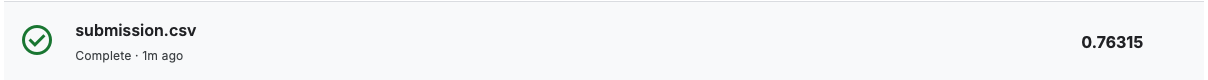